In [37]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm


# 1. Idée du modèle binomial

Le modèle binomial est une façon très simple de modéliser l'évolution d'un prix. A chaque période, le prix ne peut faire que deux choses:

- monter  
- baisser  

#2. Dynamique du prix

Si le prix aujourd'hui est $S_t$, alors au temps suivant:

$$
S_{t+\Delta t} =
\begin{cases}
S_t \cdot u \quad (\text{hausse}) \\
S_t \cdot d \quad (\text{baisse})
\end{cases}
$$

où:

- $u > 1$ : facteur de hausse  
- $d < 1$ : facteur de baisse  

Après plusieurs périodes, on obtient un arbre binomial:

- à chaque étape , on a  deux branches  
- après $N$ périodes, il y a plusieurs trajectoires possibles  

Après $n$ périodes, le prix su sous-jacent est:

$$
S_{n,j} = S_0 \cdot u^j \cdot d^{\,n-j}
$$
où:
- $j$ = nombre de hausses  
- $n - j$ = nombre de baisses  

Le modèle impose la condition $d < e^{r\Delta t} < u$ afin d’éviter toute opportunité d’arbitrage, car sinon l’actif ou le placement sans risque dominerait systématiquement l’autre, avec $r$ le taux d'intérêt sans risque

Le payoff d'un call européen à maturité est: $ \max(S_T - K, 0)$ et celui d'un put européen à maturité est:  $ \max(K - S_T, 0)$

# Pricing par induction backward

Le pricing d'une option dans le modèle binomial repose sur une procédure de récurrence arrière (backward induction)

## Etape 1: Calcul du payoff à maturité

À la date finale $T$, on calcule la valeur de l'option pour chaque nœud:

$$
C_{T,j}= \max(S_{N,j} - K, 0)
$$

## Etape 2: Probabilité risque-neutre

On définit la probabilité risque-neutre: $p = \frac{e^{r\Delta t} - d}{u - d}$

## Étape 3 : Induction backward

Pour chaque nœud intermédiaire $(n,j)$, la valeur de l'option est donnée par:

$$
C_{n,j} = e^{-r\Delta t} \left[ p \, C_{n+1,j+1} + (1-p)\, C_{n+1,j} \right]
$$

On applique cette formule de manière récursive en partant de $n = N-1$ jusqu'à $n = 0$. Et la valeur du cal aujourd'hui est: $C_0 = C_{0,0}$

In [44]:
def binomial_call_price(S0, K, T, r, sigma, N):
    dt = T / N
    #on choisit u et d pour que binomial converge vers black sholes
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    # Probabilité risque-neutre
    p = (np.exp(r * dt) - d) / (u - d)

    if p < 0 or p > 1:
       raise ValueError("Condition d'absence d'arbitrage non respectée.")

    # Prix du sous-jacent à maturité
    ST = np.array([
        S0 * (u ** j) * (d ** (N - j))
        for j in range(N + 1)
    ])
    call_values = np.maximum(ST - K, 0)

    # Backward induction
    for n in range(N - 1, -1, -1):
        call_values = np.exp(-r * dt) * ( p * call_values[1:n+2] + (1 - p) * call_values[0:n+1] )

    return call_values[0]

In [52]:
binomial_call_price(100, 100, 1, 0.05, 0.2, 100)


np.float64(10.430611662249142)

In [53]:
def bs_call_price(S0, K, T, r, sigma):
  d1=(np.log(S0/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
  d2=d1-sigma*np.sqrt(T)
  price=S0*norm.cdf(d1)-np.exp(-r*T)*K*norm.cdf(d2)

  return price

In [54]:
bs_call_price(100, 100, 1, 0.05, 0.2)

np.float64(10.450583572185565)

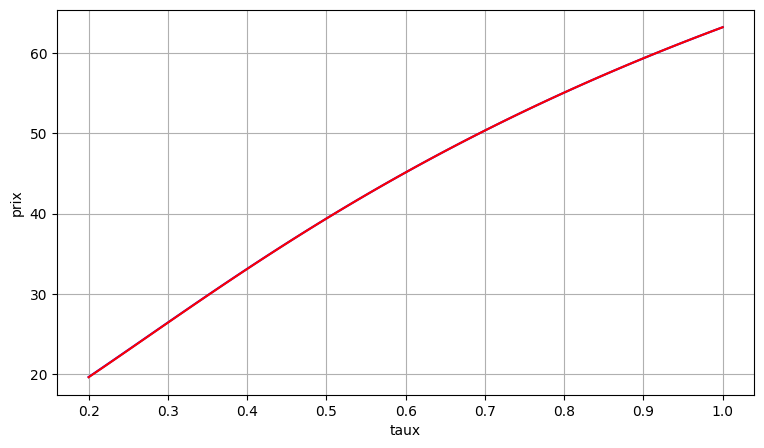

In [66]:
taux=np.linspace(0.2,1,100)
prix_bn=[]
prix_bs=[]
for r in taux:
  prix_bn.append(binomial_call_price(100, 100, 1, r, 0.2, 100))
  prix_bs.append(bs_call_price(100, 100, 1, r, 0.2))
plt.figure(figsize=(9,5))
plt.plot(taux,prix_bs,'b')
plt.plot(taux,prix_bn,'r')
plt.xlabel("taux")
plt.ylabel("prix")
plt.grid(True)


Cette superposition des courbes montre que le modèle binomial converge vers le modèle de Black-Scholes lorsque le nombre de périodes augmente, confirmant ainsi que Black-Scholes peut être vu comme la limite continue du modèle binomial.